# Part I: Import Libary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
dataset = pd.read_parquet("./data_warehouse/wheat_dollars_per_planted_acre.gzip")
dataset.dropna(inplace= True)
dataset

,year,region,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,...,repairs,secondary_product_silage_straw_grazing,seed,taxes_and_insurance,total_allocated_overhead,total_costs_listed,total_gross_value_of_production,total_operating_costs,value_of_production_less_operating_costs,value_of_production_less_total_costs_listed
0,1998,U.S. total,43.00,7.36,6.77,18.61,6.14,6.59,2.12,1.34,...,9.00,3.32,7.61,3.70,107.78,165.19,114.27,57.41,56.86,-50.92
1,1998,Heartland,38.60,3.76,6.46,37.91,4.36,7.21,1.30,1.76,...,7.19,13.58,13.25,3.26,130.28,205.47,139.55,75.19,64.36,-65.92
2,1998,Northern Crescent,36.19,3.05,10.92,33.69,3.82,7.89,0.37,1.74,...,5.93,54.11,13.32,4.02,129.83,204.29,192.28,74.46,117.82,-12.01
3,1998,Northern Great Plains,41.23,10.61,4.04,14.78,4.25,6.32,1.45,1.19,...,8.10,1.74,7.64,3.76,98.62,149.39,101.84,50.77,51.07,-47.55
4,1998,Prairie Gateway,40.66,3.30,8.07,14.27,7.03,5.67,1.77,1.12,...,8.84,2.24,5.13,3.03,95.11,143.02,105.98,47.91,58.07,-37.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,2024,Northern Crescent,142.40,26.16,17.55,98.22,13.33,11.08,2.29,5.34,...,33.33,52.18,30.85,6.45,330.33,557.88,549.11,227.55,321.56,-8.77
237,2024,Northern Great Plains,147.08,21.94,11.47,51.78,8.98,11.98,1.94,3.44,...,31.35,4.61,17.42,8.53,252.08,398.72,262.76,146.64,116.12,-135.96
238,2024,Prairie Gateway,117.70,9.53,17.90,50.69,13.46,11.80,2.95,3.25,...,29.93,4.90,13.31,6.26,199.10,337.57,252.00,138.47,113.53,-85.57
240,2024,Basin and Range,135.15,32.95,17.16,65.40,15.95,15.52,5.16,4.53,...,34.23,10.33,22.03,13.72,264.70,457.75,359.99,193.05,166.94,-97.76


In [4]:
cate_column = pd.read_parquet("./data_warehouse/wheat_column_name_category.gzip")
cate_column

,category,column_name
0,Gross value of production,primary_product_grain
1,Gross value of production,secondary_product_silage_straw_grazing
2,Gross value of production,total_gross_value_of_production
3,Operating costs,seed
4,Operating costs,fertilizer_1
5,Operating costs,chemicals
6,Operating costs,custom_services
7,Operating costs,fuel_lube_and_electricity
8,Operating costs,repairs
9,Operating costs,other_variable_expenses_2


In [5]:
cate_column_1 = cate_column.loc[ cate_column['column_name'].isin(['capital_recovery_of_machinery_and_equipment',
       'chemicals', 'custom_services', 'fertilizer_1',
       'fuel_lube_and_electricity', 'general_farm_overhead', 'hired_labor',
       'interest_on_operating_inputs', 'opportunity_cost_of_land',
       'opportunity_cost_of_unpaid_labor', 'other_variable_expenses_2', 'repairs', 'seed', 'taxes_and_insurance']),:]
cate_column_1

,category,column_name
3,Operating costs,seed
4,Operating costs,fertilizer_1
5,Operating costs,chemicals
6,Operating costs,custom_services
7,Operating costs,fuel_lube_and_electricity
8,Operating costs,repairs
9,Operating costs,other_variable_expenses_2
10,Operating costs,interest_on_operating_inputs
12,Allocated overhead,hired_labor
13,Allocated overhead,opportunity_cost_of_unpaid_labor


In [6]:
seed_data = pd.read_parquet("./data_warehouse/wheat_dollars_per_bushel_at_harvest.gzip")
seed_data.dropna(inplace= True)
seed_data

,year,region,price
0,1998,U.S. total,2.68
1,1998,Heartland,2.47
2,1998,Northern Crescent,2.33
3,1998,Northern Great Plains,2.91
4,1998,Prairie Gateway,2.66
...,...,...,...
236,2024,Northern Crescent,5.70
237,2024,Northern Great Plains,5.40
238,2024,Prairie Gateway,5.69
240,2024,Basin and Range,5.31


## Part II.b: Explain data

## Basic Identifiers
- **year**: The year of the data (201 non-null, integer)
- **region**: Geographic area/location of the farm operation (object/string)

## Input Costs \& Expenses

### Capital \& Equipment
- **capital\_recovery\_of\_machinery\_and\_equipment**: Depreciation/amortization costs for farm machinery and equipment over time

### Production Inputs
- **chemicals**: Cost of agricultural chemicals (herbicides, pesticides, fungicides)
- **fertilizer\_1**: Cost of fertilizer inputs (likely synthetic/commercial fertilizers)
- **fuel\_lube\_and\_electricity**: Energy costs for farm operations
- **seed**: Cost of planting seeds
- **repairs**: Maintenance and repair costs for equipment and facilities

### Services \& Labor
- **custom\_services**: Fees paid for hired custom work (e.g., custom harvesting, spraying, trucking)
- **hired\_labor**: Wages paid to employed farm workers

### Financial Costs
- **interest\_on\_operating\_inputs**: Interest paid on loans for operating expenses
- **taxes\_and\_insurance**: Property taxes and insurance premiums

## Opportunity Costs (Economic concepts)
- **opportunity\_cost\_of\_land**: The potential rental income foregone by using owned land
- **opportunity\_cost\_of\_unpaid\_labor**: The value of unpaid family labor (what they could earn elsewhere)

## Overhead
- **general\_farm\_overhead**: General administrative and miscellaneous farm expenses
- **other\_variable\_expenses\_2**: Other variable costs not categorized elsewhere
- **total\_allocated\_overhead**: Sum of all overhead costs allocated to the operation

## Revenue/Output
- **primary\_product\_grain**: Revenue from main grain crop sales
- **secondary\_product\_silage\_straw\_grazing**: Revenue from by-products (silage, straw, grazing rights)
- **total\_gross\_value\_of\_production**: Total revenue from all products

## Summary/Calculated Fields
- **total\_operating\_costs**: Sum of all variable operating expenses
- **total\_costs\_listed**: Total of all costs (operating + overhead + opportunity costs)
- **value\_of\_production\_less\_operating\_costs**: Gross margin $= \text{Revenue} - \text{Operating costs}$
- **value\_of\_production\_less\_total\_costs\_listed**: Net return/profit $= \text{Revenue} - \text{All costs}$

# Part II: EDA

## Part II.a: Import data

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 241
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   year                                         201 non-null    int64  
 1   region                                       201 non-null    str    
 2   capital_recovery_of_machinery_and_equipment  201 non-null    float64
 3   chemicals                                    201 non-null    float64
 4   custom_services                              201 non-null    float64
 5   fertilizer_1                                 201 non-null    float64
 6   fuel_lube_and_electricity                    201 non-null    float64
 7   general_farm_overhead                        201 non-null    float64
 8   hired_labor                                  201 non-null    float64
 9   interest_on_operating_inputs                 201 non-null    float64
 10  opportunity_cost_o

In [8]:
df_1 = dataset.iloc[:,:]
df_1['real_spent'] = dataset.loc[:, ['capital_recovery_of_machinery_and_equipment',
       'chemicals', 'custom_services', 'fertilizer_1',
       'fuel_lube_and_electricity', 'general_farm_overhead', 'hired_labor',
       'interest_on_operating_inputs', 'other_variable_expenses_2', 'repairs', 'seed', 'taxes_and_insurance']].sum(axis=1, numeric_only=True)
df_1

,year,region,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,...,secondary_product_silage_straw_grazing,seed,taxes_and_insurance,total_allocated_overhead,total_costs_listed,total_gross_value_of_production,total_operating_costs,value_of_production_less_operating_costs,value_of_production_less_total_costs_listed,real_spent
0,1998,U.S. total,43.00,7.36,6.77,18.61,6.14,6.59,2.12,1.34,...,3.32,7.61,3.70,107.78,165.19,114.27,57.41,56.86,-50.92,112.82
1,1998,Heartland,38.60,3.76,6.46,37.91,4.36,7.21,1.30,1.76,...,13.58,13.25,3.26,130.28,205.47,139.55,75.19,64.36,-65.92,125.56
2,1998,Northern Crescent,36.19,3.05,10.92,33.69,3.82,7.89,0.37,1.74,...,54.11,13.32,4.02,129.83,204.29,192.28,74.46,117.82,-12.01,122.93
3,1998,Northern Great Plains,41.23,10.61,4.04,14.78,4.25,6.32,1.45,1.19,...,1.74,7.64,3.76,98.62,149.39,101.84,50.77,51.07,-47.55,103.53
4,1998,Prairie Gateway,40.66,3.30,8.07,14.27,7.03,5.67,1.77,1.12,...,2.24,5.13,3.03,95.11,143.02,105.98,47.91,58.07,-37.04,99.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,2024,Northern Crescent,142.40,26.16,17.55,98.22,13.33,11.08,2.29,5.34,...,52.18,30.85,6.45,330.33,557.88,549.11,227.55,321.56,-8.77,389.77
237,2024,Northern Great Plains,147.08,21.94,11.47,51.78,8.98,11.98,1.94,3.44,...,4.61,17.42,8.53,252.08,398.72,262.76,146.64,116.12,-135.96,316.17
238,2024,Prairie Gateway,117.70,9.53,17.90,50.69,13.46,11.80,2.95,3.25,...,4.90,13.31,6.26,199.10,337.57,252.00,138.47,113.53,-85.57,277.18
240,2024,Basin and Range,135.15,32.95,17.16,65.40,15.95,15.52,5.16,4.53,...,10.33,22.03,13.72,264.70,457.75,359.99,193.05,166.94,-97.76,362.60


In [9]:
df_1['real_value_of_production'] = df_1.loc[:,'total_gross_value_of_production'].values - df_1.loc[:,'real_spent'].values
df_1['real_value_of_production']

0        1.45
1       13.99
2       69.35
3       -1.69
4        6.94
        ...  
236    159.34
237    -53.41
238    -25.18
240     -2.61
241    -52.90
Name: real_value_of_production, Length: 201, dtype: float64

##### Reajust data for new columns
* 'opportunity_cost_of_land', 'opportunity_cost_of_unpaid_labor' just a opportunity cost just a predict and no data showing and create noise so we will remove to have the correct number

In [10]:
df_us = df_1.loc[dataset['region'] == "U.S. total"]

In [11]:
pd.concat([df_us.iloc[:,2:12],df_us.iloc[:,[14]], df_us.iloc[:,[16,17,20]]],axis = 1).describe()

,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,opportunity_cost_of_land,opportunity_cost_of_unpaid_labor,repairs,seed,taxes_and_insurance,total_gross_value_of_production
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,76.728889,12.633704,9.972593,38.672593,13.678148,9.405556,2.699630,1.021852,51.733333,17.599259,18.799630,12.426667,6.191852,217.284815
std,26.937381,4.384861,3.197628,15.832116,4.646114,1.744427,0.709211,1.083303,10.834324,2.280379,7.262637,4.173168,1.462330,83.446573
min,43.000000,6.940000,5.670000,16.950000,6.140000,6.590000,1.970000,0.040000,37.520000,14.850000,9.000000,6.140000,3.700000,95.170000
25%,50.365000,8.570000,6.770000,25.030000,10.815000,8.075000,2.190000,0.130000,40.395000,15.990000,11.935000,7.975000,5.625000,137.580000
50%,77.370000,14.160000,9.960000,42.520000,12.430000,9.370000,2.450000,0.640000,52.650000,16.930000,20.330000,14.110000,6.480000,224.610000
75%,94.855000,15.675000,13.570000,46.115000,17.015000,11.095000,2.830000,1.345000,62.115000,18.525000,24.260000,15.575000,7.095000,286.170000
max,131.510000,21.490000,15.310000,82.760000,25.250000,12.020000,4.440000,4.200000,66.070000,23.040000,31.430000,18.830000,9.050000,367.000000


In [12]:
desc_whe = pd.concat([df_us.iloc[:,2:12],df_us.iloc[:,[14]], df_us.iloc[:,[16,17]]],axis = 1).describe()
desc_whe

,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,opportunity_cost_of_land,opportunity_cost_of_unpaid_labor,repairs,seed,taxes_and_insurance
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,76.728889,12.633704,9.972593,38.672593,13.678148,9.405556,2.699630,1.021852,51.733333,17.599259,18.799630,12.426667,6.191852
std,26.937381,4.384861,3.197628,15.832116,4.646114,1.744427,0.709211,1.083303,10.834324,2.280379,7.262637,4.173168,1.462330
min,43.000000,6.940000,5.670000,16.950000,6.140000,6.590000,1.970000,0.040000,37.520000,14.850000,9.000000,6.140000,3.700000
25%,50.365000,8.570000,6.770000,25.030000,10.815000,8.075000,2.190000,0.130000,40.395000,15.990000,11.935000,7.975000,5.625000
50%,77.370000,14.160000,9.960000,42.520000,12.430000,9.370000,2.450000,0.640000,52.650000,16.930000,20.330000,14.110000,6.480000
75%,94.855000,15.675000,13.570000,46.115000,17.015000,11.095000,2.830000,1.345000,62.115000,18.525000,24.260000,15.575000,7.095000
max,131.510000,21.490000,15.310000,82.760000,25.250000,12.020000,4.440000,4.200000,66.070000,23.040000,31.430000,18.830000,9.050000


In [13]:
desc_whe.loc['mean',cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].values

array([ 2.69962963, 17.59925926, 76.72888889, 51.73333333,  6.19185185,
        9.40555556])

In [14]:
desc_whe[desc_whe.columns.difference(desc_whe.loc[:,cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].columns.values)].loc['mean',:]

chemicals                       12.633704
custom_services                  9.972593
fertilizer_1                    38.672593
fuel_lube_and_electricity       13.678148
interest_on_operating_inputs     1.021852
repairs                         18.799630
seed                            12.426667
Name: mean, dtype: float64

In [15]:
pd.concat([dataset.iloc[:,2:12],dataset.iloc[:,[14]], dataset.iloc[:,[16,17]]],axis = 1).describe().columns.values

<ArrowStringArray>
['capital_recovery_of_machinery_and_equipment',
                                   'chemicals',
                             'custom_services',
                                'fertilizer_1',
                   'fuel_lube_and_electricity',
                       'general_farm_overhead',
                                 'hired_labor',
                'interest_on_operating_inputs',
                    'opportunity_cost_of_land',
            'opportunity_cost_of_unpaid_labor',
                                     'repairs',
                                        'seed',
                         'taxes_and_insurance']
Length: 13, dtype: str

In [16]:
df_1.loc[df_1["year"] == 2024 , 
cate_column_1.loc[cate_column_1['category'] == "Allocated overhead", 'column_name'].values.tolist()].values[0]

array([  2.99,  16.68, 131.51,  66.07,   7.6 ,  12.02])

In [17]:
line_style = dict(marker = "o", 
         markerfacecolor = "red")
tle_style = dict(fontsize = 13,
         family= "Times New Roman")

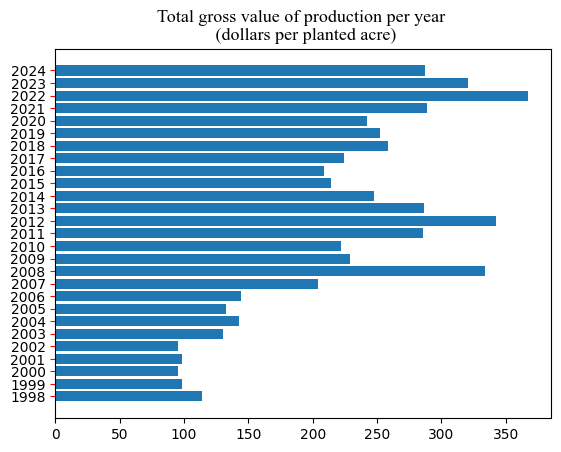

In [18]:
plt.barh(df_us['year'], df_us['total_gross_value_of_production'])
plt.tick_params(axis="y", color = "red", labelrotation=0)
plt.yticks(df_us['year'])
plt.title("Total gross value of production per year \n (dollars per planted acre)",
           **tle_style, 
          color ="black")
plt.show()

###### With the plot showing:
* After the highest grow in 2022 the value start to falling back 

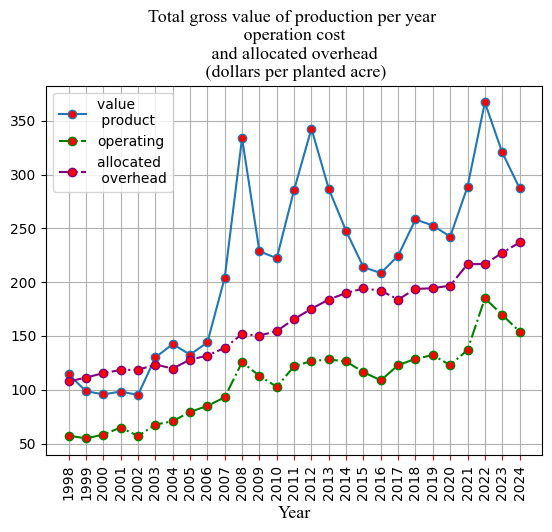

In [19]:
plt.plot(df_us['year'], df_us['total_gross_value_of_production'], **line_style, label="value \n product")
plt.plot(df_us['year'], df_us['total_operating_costs'], 
         **line_style,
        linestyle = "dashdot",
        color="green", label="operating")
plt.plot(df_us['year'], df_us['total_allocated_overhead'], 
         **line_style,
        linestyle = "dashdot",
        color="purple", label="allocated \n overhead")
plt.grid()
plt.title("Total gross value of production per year \n operation cost \n and allocated overhead \n (dollars per planted acre)",
         **tle_style, 
          color ="black")
plt.xlabel("Year",
           **tle_style, 
          color ="black")
'''plt.ylabel("Total operation cost",
           **tle_style, 
          color ="black")'''
plt.tick_params(axis="x", color = "red", labelrotation=90)
plt.xticks(df_us['year'])
plt.legend(loc='upper left')
plt.show()

###### With the plot showing:
* After the highest grow in 2022 the value start to falling back this happen to both 'value product' and 'oprating cost'
* For 'allocated overhead' keep growing after 2017 and 2022 is still growing even 'value product' and 'oprating cost' falling down

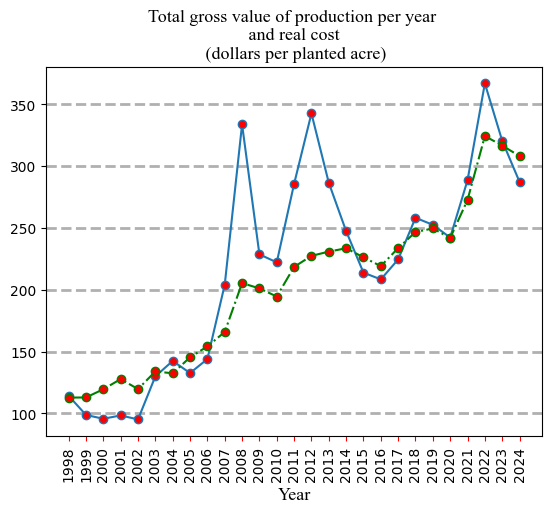

In [20]:
plt.plot(df_us['year'], df_us['total_gross_value_of_production'], **line_style)
plt.plot(df_us['year'], df_us['real_spent'], 
         **line_style,
        linestyle = "dashdot",
        color="green")
plt.grid(axis="y",
        linewidth= 2,
        linestyle="dashed")
plt.title("Total gross value of production per year \n and real cost \n (dollars per planted acre)",
           **tle_style, 
          color ="black")
plt.xlabel("Year",
           **tle_style, 
          color ="black")
'''plt.ylabel("Total real cost",
           **tle_style, 
          color ="black")'''
plt.tick_params(axis="x", color = "red", labelrotation=90)
plt.xticks(df_us['year'])
plt.show()

###### With the plot showing:
* After re-adjust the real spending on production we can see most of the time 'Total gross value of production' and 'real cost' are having the same trend 

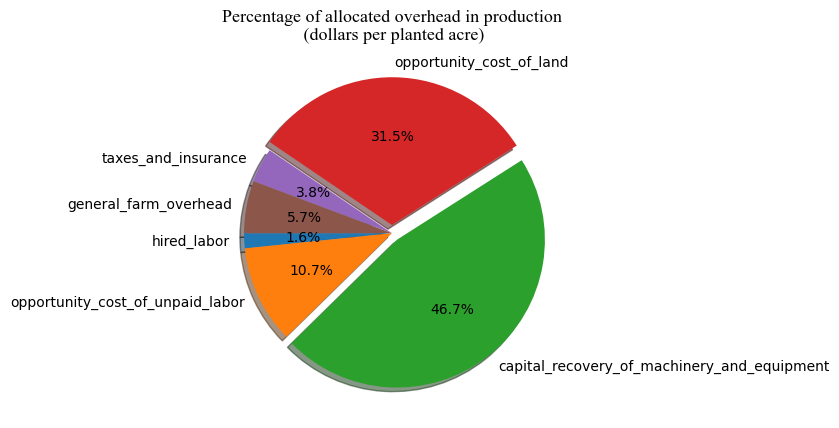

In [21]:
value = desc_whe.loc['mean',cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].values
category = desc_whe.loc[:,cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].columns.values
plt.pie(value, labels = category,
       autopct="%1.1f%%",
       #colors = color,
       explode=[  0,  0, 0.056,  0.055,   0 ,  0],
       shadow= True,
       startangle = 180)
plt.title("Percentage of allocated overhead in production\n (dollars per planted acre)",
           **tle_style, 
          color ="black")
plt.show()

###### With the plot showing:
* The highest percentage is 'capital_recovery_of_machinery_and_equipment' is taking 46.7%
* The second hight percentage is 'opportunity_cost_of_land' is taking 31.5%
* The third high percentage is 'opportunity_cost_of_unpaid_labor' is taking 10.7%
* The lowest percentage is 'hired_labor' is taking 1.6%

Result:
* With percentage of pieplot showing the most of overhead cost in production nearly 88.9 is falling into the columns which is a budget for operation or just opportunity cost so will create a lot of noise in the data this is the main reason need to remove the opportunity cost column

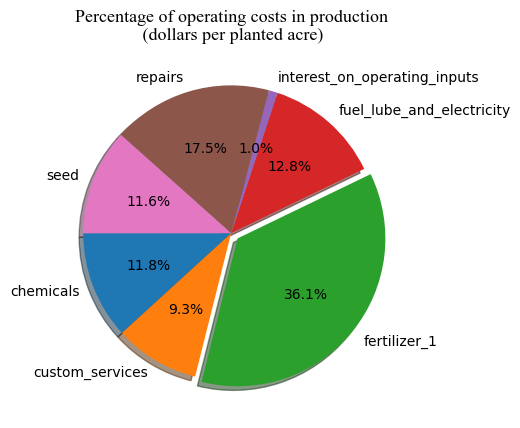

In [22]:
value = desc_whe[desc_whe.columns.difference(desc_whe.loc[:,cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].columns.values)].loc['mean',:]
category = desc_whe[desc_whe.columns.difference(desc_whe.loc[:,cate_column_1.loc[cate_column_1['category']=='Allocated overhead','column_name']].columns.values)].columns.values
plt.pie(value, labels = category,
       autopct="%1.1f%%",
       #colors = color,
       explode=[  0,  0, 0.056 ,   0 ,  0, 0, 0],
       shadow= True,
       startangle = 180)
plt.title("Percentage of operating costs in production\n (dollars per planted acre)",
           **tle_style, 
          color ="black")
plt.show()

###### With the plot showing:
* The highest percentage is 'fertilizer_1' is taking 36.1%
* The second hight percentage is 'repair' is taking 17.5%
* The third high percentage is 'fuel_lube_and_electricity' is taking 12.8%
* The lowest percentage is 'interest_on_operation_inputs' is taking 1.0%

Result:
* With percentage of pieplot showing the real cost of the normal agriculture: fertilizer, farm tools repair, fuel and electricity for machine and watering
* The 'repair' column is proving we need the budget from 'capital_recovery_of_machinery_and_equipment' for machine and tools

### New column explanation
* yield: Estimated yield (Bushels per planted acre)

In [100]:
df_yield=pd.merge(df_1.loc[df_1.region == "U.S. total"].iloc[:,[0,1,13,5,16]], seed_data.loc[seed_data.region == "U.S. total"], on=["year", "region"])
df_yield["yield"] = df_yield["primary_product_grain"]/df_yield["price"]
df_yield

,year,region,primary_product_grain,fertilizer_1,seed,price,yield
0,1998,U.S. total,110.95,18.61,7.61,2.68,41.399254
1,1999,U.S. total,95.73,16.95,6.38,2.48,38.600806
2,2000,U.S. total,92.50,17.28,6.14,2.46,37.601626
3,2001,U.S. total,95.22,23.90,6.34,2.76,34.500000
4,2002,U.S. total,91.51,17.71,6.65,3.28,27.899390
5,2003,U.S. total,126.48,23.11,7.60,3.11,40.668810
6,2004,U.S. total,136.91,22.84,7.89,3.44,39.799419
7,2005,U.S. total,126.48,26.16,8.06,3.17,39.899054
8,2006,U.S. total,136.78,28.44,8.46,4.12,33.199029
9,2007,U.S. total,196.35,32.69,9.77,5.25,37.400000


In [101]:
df_yield.isna().sum()

year                     0
region                   0
primary_product_grain    0
fertilizer_1             0
seed                     0
price                    0
yield                    0
dtype: int64

In [102]:
top_5 = df_yield.sort_values(by='primary_product_grain', ascending=False)
top_5.head(5)

,year,region,primary_product_grain,fertilizer_1,seed,price,yield
24,2022,U.S. total,358.56,82.76,18.08,8.95,40.062570
14,2012,U.S. total,332.00,46.08,15.33,7.58,43.799472
10,2008,U.S. total,324.62,52.51,16.02,7.86,41.300254
25,2023,U.S. total,311.54,66.09,18.83,7.52,41.428191
23,2021,U.S. total,282.15,50.41,15.11,6.67,42.301349


In [108]:
df_yield.sort_values(by='fertilizer_1', ascending=False).iloc[:,[0,1,3]].head(5)

,year,region,fertilizer_1
24,2022,U.S. total,82.76
25,2023,U.S. total,66.09
26,2024,U.S. total,56.18
10,2008,U.S. total,52.51
23,2021,U.S. total,50.41


In [107]:
df_yield.sort_values(by='seed', ascending=False).iloc[:,[0,1,4]].head(5)

,year,region,seed
25,2023,U.S. total,18.83
24,2022,U.S. total,18.08
26,2024,U.S. total,17.61
17,2015,U.S. total,16.12
15,2013,U.S. total,16.06


In [105]:
df_yield.sort_values(by='yield', ascending=False).iloc[:,[0,1,-1]].head(5)

,year,region,yield
21,2019,U.S. total,53.256466
22,2020,U.S. total,51.481562
18,2016,U.S. total,50.798982
26,2024,U.S. total,50.593128
20,2018,U.S. total,48.644914


In [106]:
df_yield.sort_values(by='price', ascending=False).iloc[:,[0,1,-2]].head(5)

,year,region,price
24,2022,U.S. total,8.95
10,2008,U.S. total,7.86
14,2012,U.S. total,7.58
25,2023,U.S. total,7.52
13,2011,U.S. total,7.35


#### In the top 5 rows of highest 'primary_product_grain' we can see:
* The 'fertilizer_1' nearly the same range from 82.76 to 50.41
* The 'seed' also nearly the same range from 18.08 to 16.06
* The 'price' also the same range from 8.95 to 7.35
* But 'yield' showing different from 53.2 to 48.6

This showing 'fertilizer_1', 'seed', 'price' are affecting the 'primary_product_grain' more than 'yield'

In [109]:
df_yield.sort_values(by='primary_product_grain', ascending=True).head(5)

,year,region,primary_product_grain,fertilizer_1,seed,price,yield
4,2002,U.S. total,91.51,17.71,6.65,3.28,27.899390
2,2000,U.S. total,92.50,17.28,6.14,2.46,37.601626
3,2001,U.S. total,95.22,23.90,6.34,2.76,34.500000
1,1999,U.S. total,95.73,16.95,6.38,2.48,38.600806
0,1998,U.S. total,110.95,18.61,7.61,2.68,41.399254


In [112]:
df_yield.sort_values(by='fertilizer_1', ascending=True).iloc[:,[0,1,3]].head(5)

,year,region,fertilizer_1
1,1999,U.S. total,16.95
2,2000,U.S. total,17.28
4,2002,U.S. total,17.71
0,1998,U.S. total,18.61
6,2004,U.S. total,22.84


In [113]:
df_yield.sort_values(by='seed', ascending=True).iloc[:,[0,1,4]].head(5)

,year,region,seed
2,2000,U.S. total,6.14
3,2001,U.S. total,6.34
1,1999,U.S. total,6.38
4,2002,U.S. total,6.65
5,2003,U.S. total,7.60


In [110]:
df_yield.sort_values(by='yield', ascending=True).iloc[:,[0,1,-1]].head(5)

,year,region,yield
4,2002,U.S. total,27.899390
8,2006,U.S. total,33.199029
3,2001,U.S. total,34.500000
16,2014,U.S. total,36.900621
9,2007,U.S. total,37.400000


In [111]:
df_yield.sort_values(by='price', ascending=True).iloc[:,[0,1,-2]].head(5)

,year,region,price
2,2000,U.S. total,2.46
1,1999,U.S. total,2.48
0,1998,U.S. total,2.68
3,2001,U.S. total,2.76
5,2003,U.S. total,3.11


#### In the top 5 rows of lowest 'primary_product_grain' we can see:
* The 'fertilizer_1' nearly the same range from 22.84 to 16.95
* The 'seed' also nearly the same range from 7.60 to 6.14
* The 'price' also the same range from 3.11 to 2.46
* But this time 'yield' showing same range from 37.4 to 27.8

This showing 'fertilizer_1', 'seed', 'price', 'yield' are nearly the same range this could happen because the price is falling so the fammer stop selling that much to stop budget drain of 'primary_product_grain'

## Region analytics

In [23]:
df_region = df_1.loc[df_1.region != "U.S. total"]
df_region

,year,region,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,...,seed,taxes_and_insurance,total_allocated_overhead,total_costs_listed,total_gross_value_of_production,total_operating_costs,value_of_production_less_operating_costs,value_of_production_less_total_costs_listed,real_spent,real_value_of_production
1,1998,Heartland,38.60,3.76,6.46,37.91,4.36,7.21,1.30,1.76,...,13.25,3.26,130.28,205.47,139.55,75.19,64.36,-65.92,125.56,13.99
2,1998,Northern Crescent,36.19,3.05,10.92,33.69,3.82,7.89,0.37,1.74,...,13.32,4.02,129.83,204.29,192.28,74.46,117.82,-12.01,122.93,69.35
3,1998,Northern Great Plains,41.23,10.61,4.04,14.78,4.25,6.32,1.45,1.19,...,7.64,3.76,98.62,149.39,101.84,50.77,51.07,-47.55,103.53,-1.69
4,1998,Prairie Gateway,40.66,3.30,8.07,14.27,7.03,5.67,1.77,1.12,...,5.13,3.03,95.11,143.02,105.98,47.91,58.07,-37.04,99.04,6.94
5,1998,Southern Seaboard,43.01,5.59,14.14,44.57,5.72,5.74,5.36,2.30,...,16.39,2.62,120.75,218.98,117.09,98.23,18.86,-101.89,154.96,-37.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,2024,Northern Crescent,142.40,26.16,17.55,98.22,13.33,11.08,2.29,5.34,...,30.85,6.45,330.33,557.88,549.11,227.55,321.56,-8.77,389.77,159.34
237,2024,Northern Great Plains,147.08,21.94,11.47,51.78,8.98,11.98,1.94,3.44,...,17.42,8.53,252.08,398.72,262.76,146.64,116.12,-135.96,316.17,-53.41
238,2024,Prairie Gateway,117.70,9.53,17.90,50.69,13.46,11.80,2.95,3.25,...,13.31,6.26,199.10,337.57,252.00,138.47,113.53,-85.57,277.18,-25.18
240,2024,Basin and Range,135.15,32.95,17.16,65.40,15.95,15.52,5.16,4.53,...,22.03,13.72,264.70,457.75,359.99,193.05,166.94,-97.76,362.60,-2.61


## Common Agricultural Analysis Patterns:

### Calculate profit margin

In [24]:
df_region['value_after_cost'] = df_region['value_of_production_less_total_costs_listed'] + df_region['capital_recovery_of_machinery_and_equipment'] + df_region['opportunity_cost_of_land'] + df_region['opportunity_cost_of_unpaid_labor']

In [25]:
df_region['profit_margin'] = df_region['value_after_cost'] / df_region['total_gross_value_of_production'] * 100

In [26]:
df_region.region.unique()

<ArrowStringArray>
[            'Heartland',     'Northern Crescent', 'Northern Great Plains',
       'Prairie Gateway',     'Southern Seaboard',       'Basin and Range',
          'Fruitful Rim',    'Mississippi Portal']
Length: 8, dtype: str

In [27]:
df_region.loc[df_region.year.isin([df_region.year.min(), 2024]),['region','year','capital_recovery_of_machinery_and_equipment','value_of_production_less_total_costs_listed', 'total_costs_listed','total_gross_value_of_production']]

,region,year,capital_recovery_of_machinery_and_equipment,value_of_production_less_total_costs_listed,total_costs_listed,total_gross_value_of_production
1,Heartland,1998,38.60,-65.92,205.47,139.55
2,Northern Crescent,1998,36.19,-12.01,204.29,192.28
3,Northern Great Plains,1998,41.23,-47.55,149.39,101.84
4,Prairie Gateway,1998,40.66,-37.04,143.02,105.98
5,Southern Seaboard,1998,43.01,-101.89,218.98,117.09
6,Basin and Range,1998,64.10,-87.51,246.63,159.12
7,Fruitful Rim,1998,63.31,-117.91,291.41,173.50
8,Mississippi Portal,1998,42.19,-64.14,194.65,130.51
235,Heartland,2024,136.13,-72.01,561.93,489.92
236,Northern Crescent,2024,142.40,-8.77,557.88,549.11


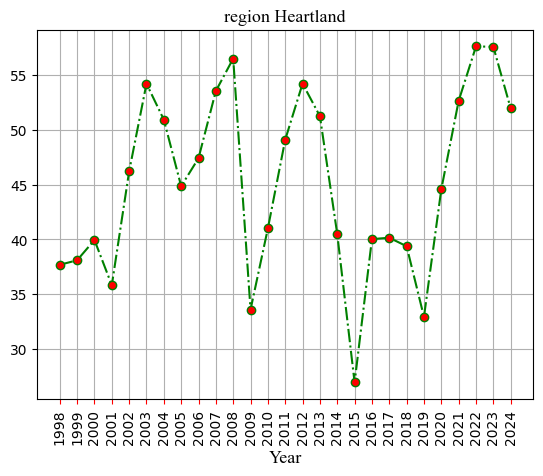

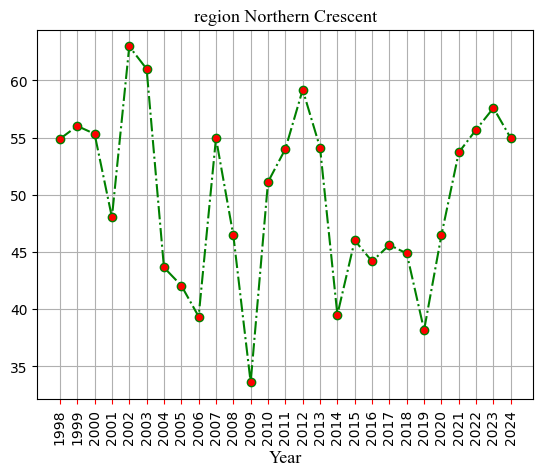

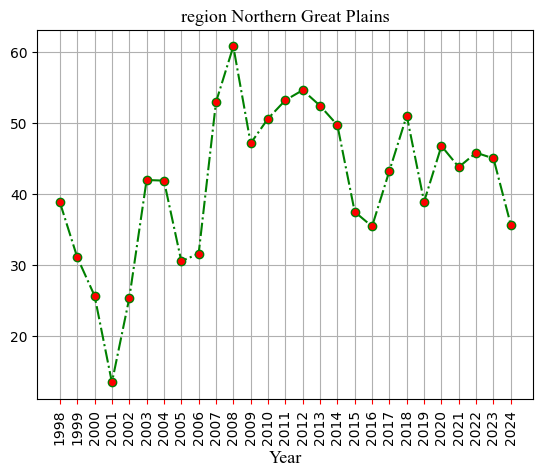

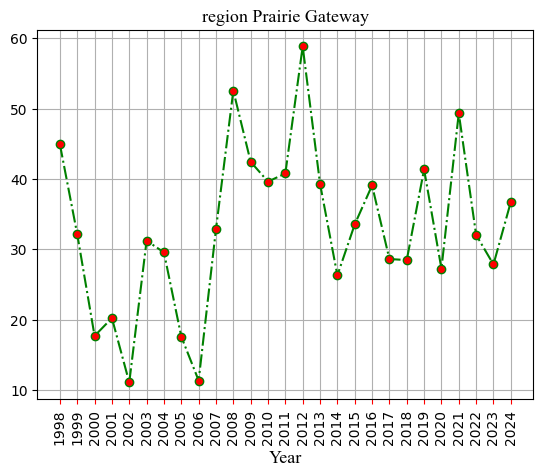

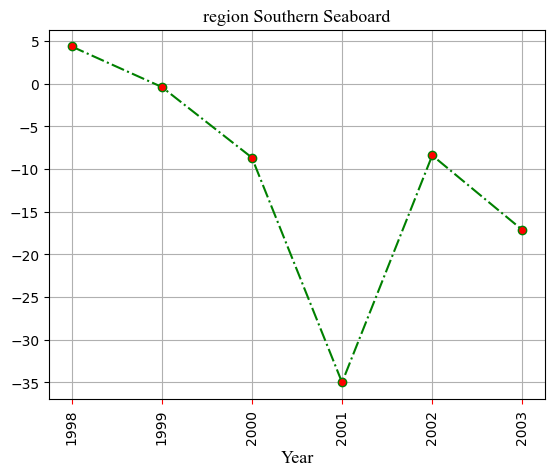

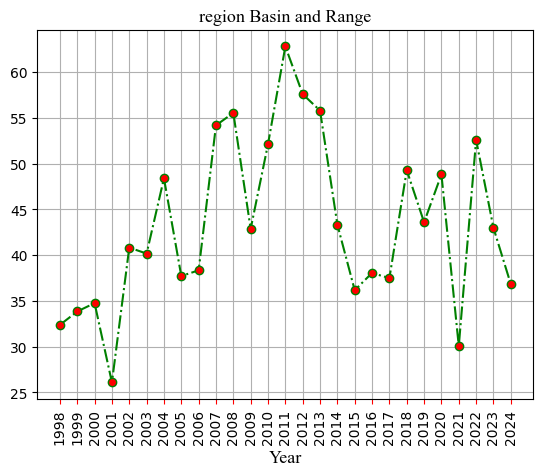

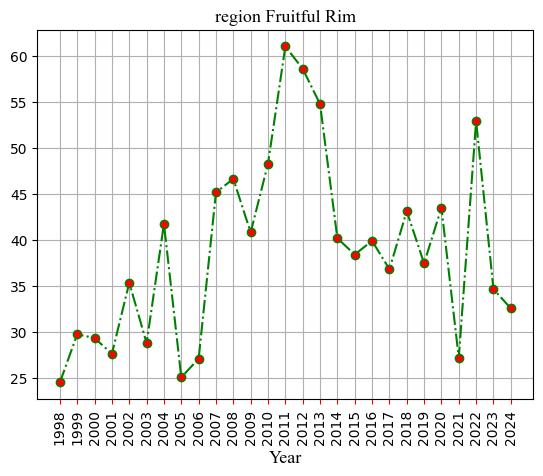

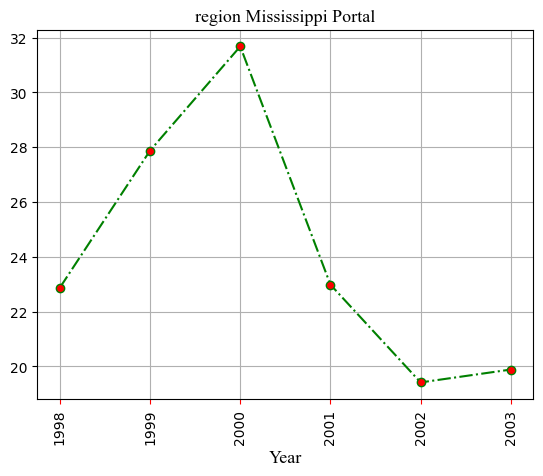

In [29]:
for i in df_region.region.unique():
    plt.plot( df_region.loc[df_region['region']==i, ['year']], df_region.loc[df_region['region']==i, ['profit_margin']], **line_style,
              linestyle = "dashdot",
              color="green", label= i)
    plt.title("region " + i,
              **tle_style, 
              color ="black")
    plt.xlabel("Year",
               **tle_style, 
               color ="black")
    plt.grid()
    plt.tick_params(axis="x", color = "red", labelrotation=90)
    plt.xticks(df_region.loc[df_region['region'] == i, 'year'].to_list())
    plt.show()

##### Profit margin
* The plot showing in 2024 except Prairie Gateway region which showing grown in nearly close to 40%

### Compare operating vs total costs

In [30]:
df_region['overhead_percentage'] = df_region['total_allocated_overhead'] / df_region['total_operating_costs'] * 100

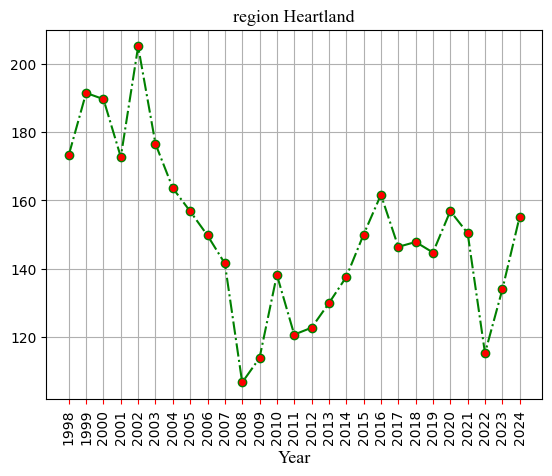

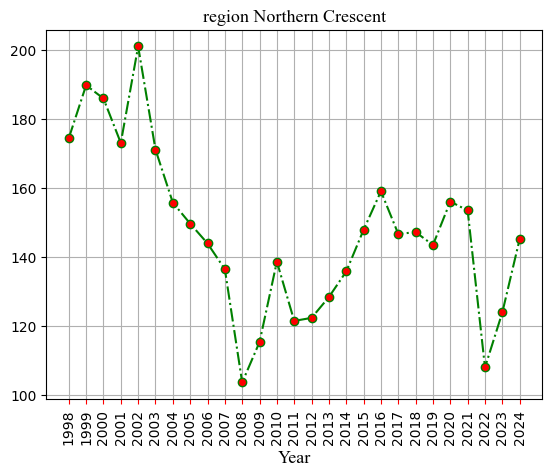

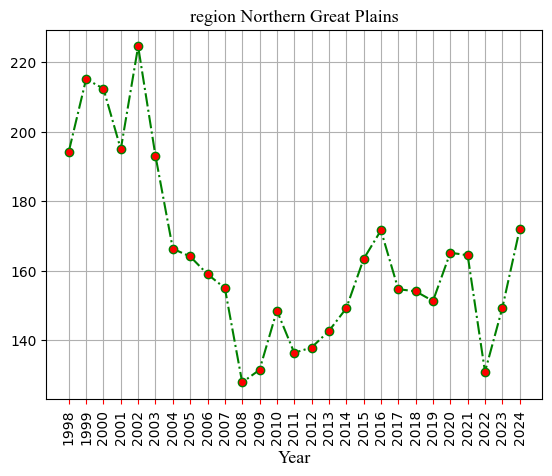

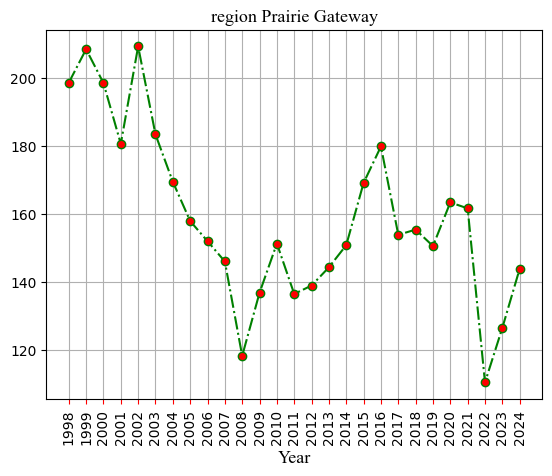

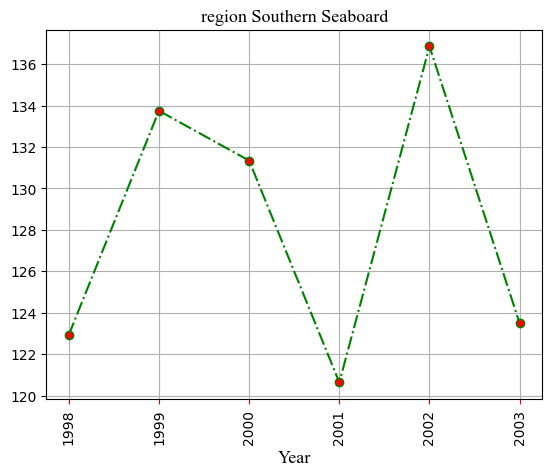

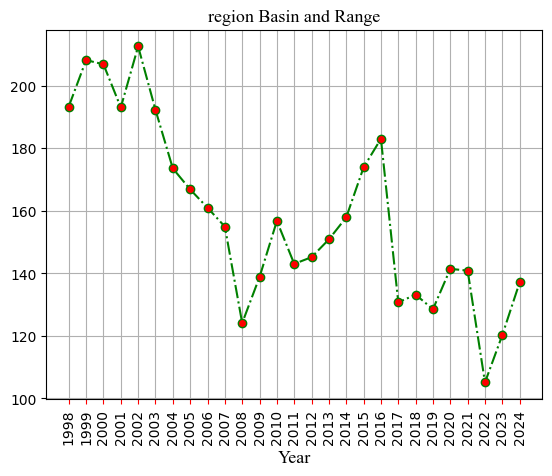

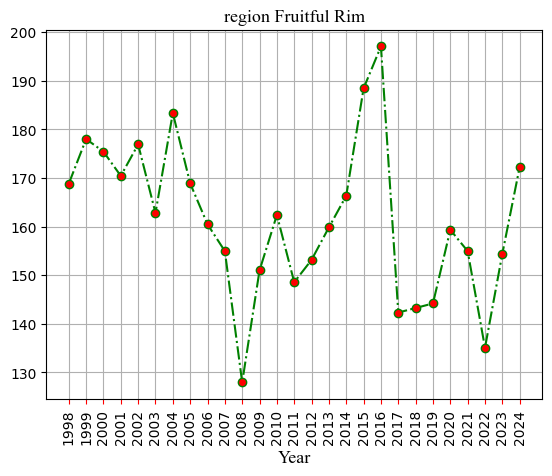

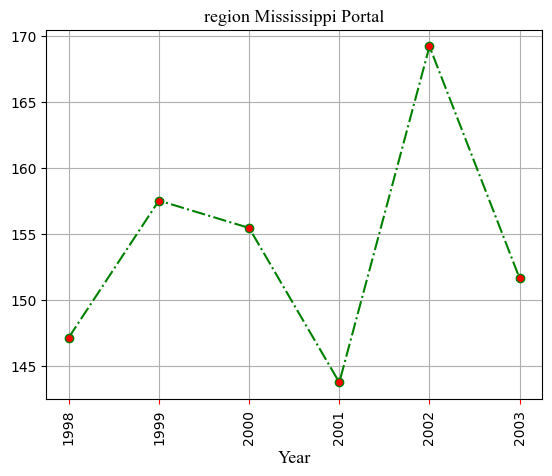

In [31]:
for i in df_region.region.unique():
    plt.plot( df_region.loc[df_region['region']==i, ['year']], df_region.loc[df_region['region']==i, ['overhead_percentage']], **line_style,
              linestyle = "dashdot",
              color="green", label= i)
    plt.title("region " + i,
              **tle_style, 
              color ="black")
    plt.xlabel("Year",
               **tle_style, 
               color ="black")
    plt.grid()
    plt.tick_params(axis="x", color = "red", labelrotation=90)
    plt.xticks(df_region.loc[df_region['region'] == i, 'year'].to_list())
    plt.show()

##### Compare operating vs total costs
* The plot showing all the regions are over 100% and growing after 2022

### Input cost breakdown

In [32]:
input_costs = ['seed', 'fertilizer_1', 'chemicals', 'fuel_lube_and_electricity']
df_region['total_input_costs'] = df_region[input_costs].sum(axis=1)

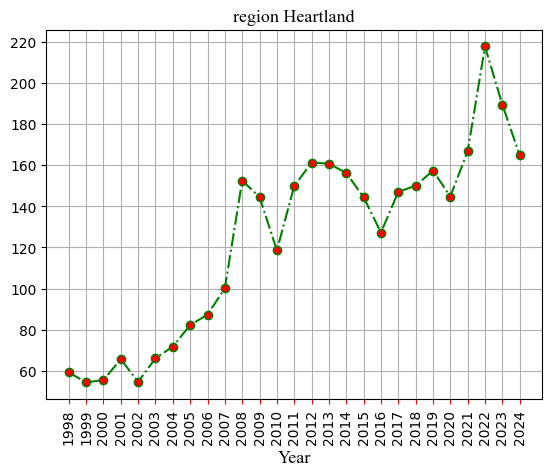

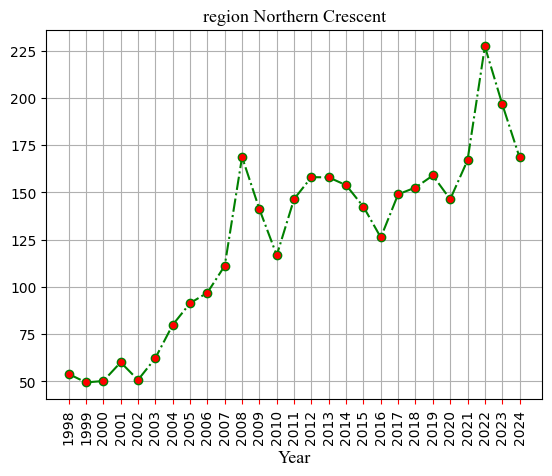

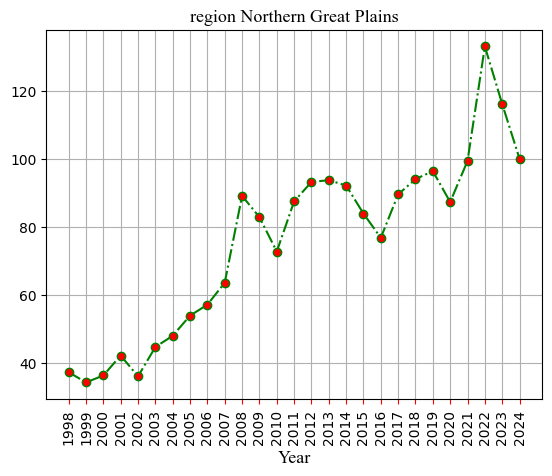

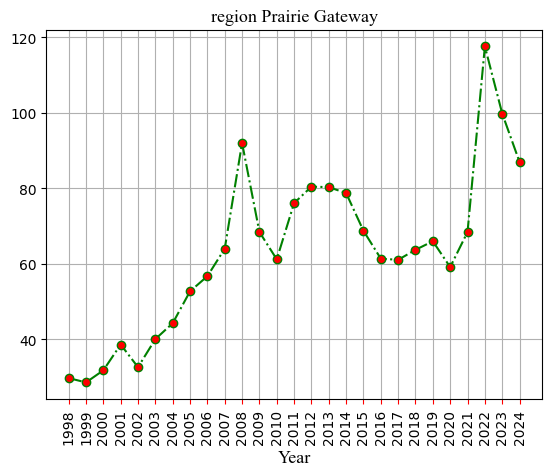

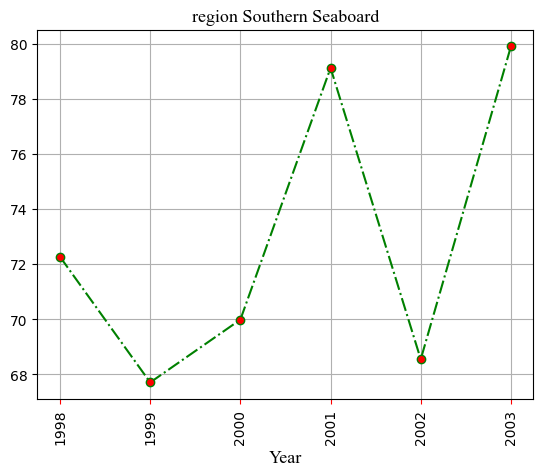

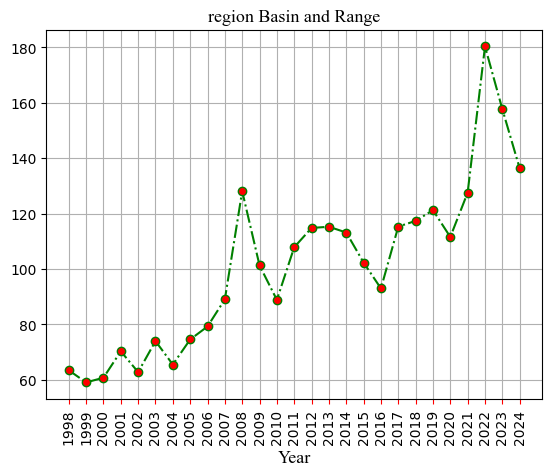

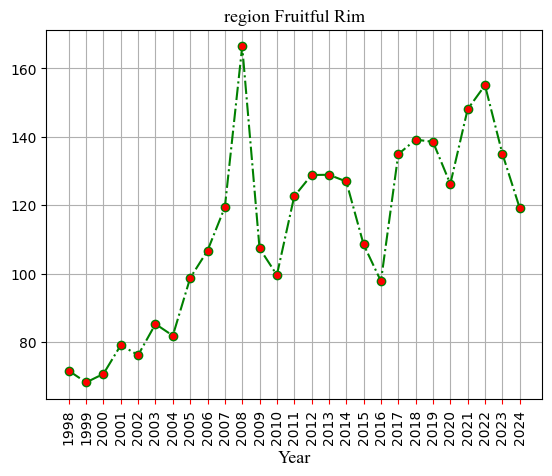

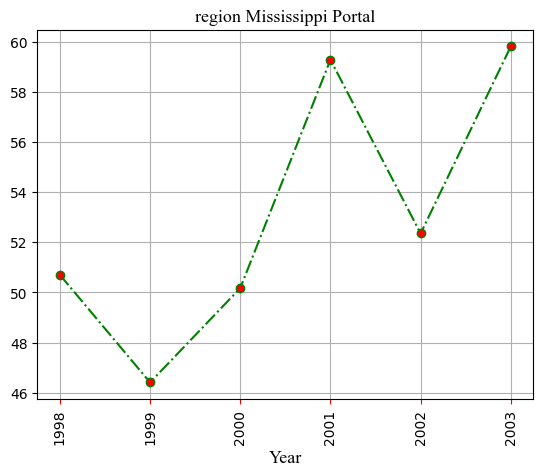

In [33]:
for i in df_region.region.unique():
    plt.plot( df_region.loc[df_region['region']==i, ['year']], df_region.loc[df_region['region']==i, ['total_input_costs']], **line_style,
              linestyle = "dashdot",
              color="green", label= i)
    plt.title("region " + i,
              **tle_style, 
              color ="black")
    plt.xlabel("Year",
               **tle_style, 
               color ="black")
    plt.grid()
    plt.tick_params(axis="x", color = "red", labelrotation=90)
    plt.xticks(df_region.loc[df_region['region'] == i, 'year'].to_list())
    plt.show()

##### Input cost breakdown
* The plot showing all the regions are over 100 and droping after 2022

### ROI analysis

In [34]:
df_region['return_on_operating_costs'] = df_region['value_of_production_less_operating_costs'] / df_region['total_operating_costs'] * 100

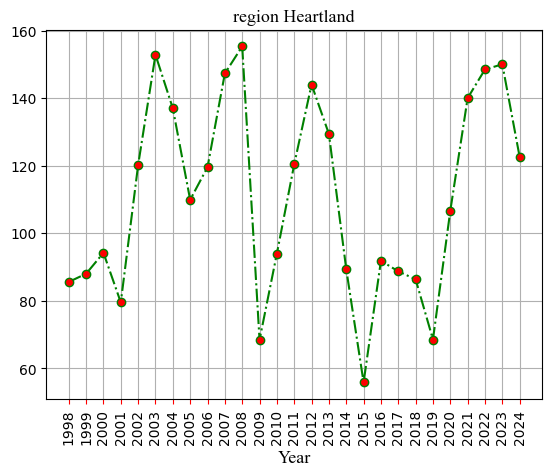

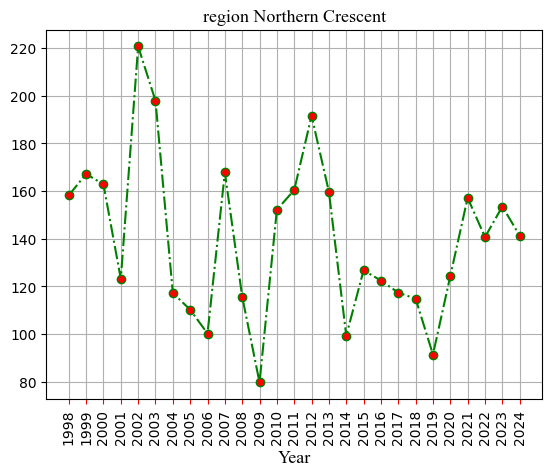

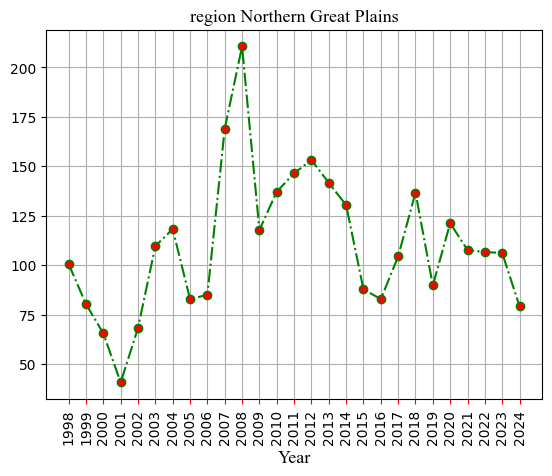

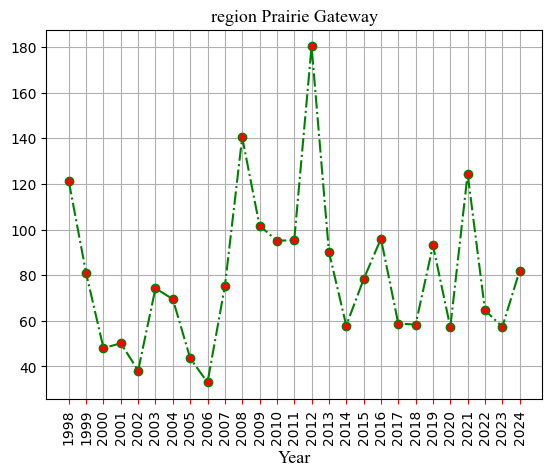

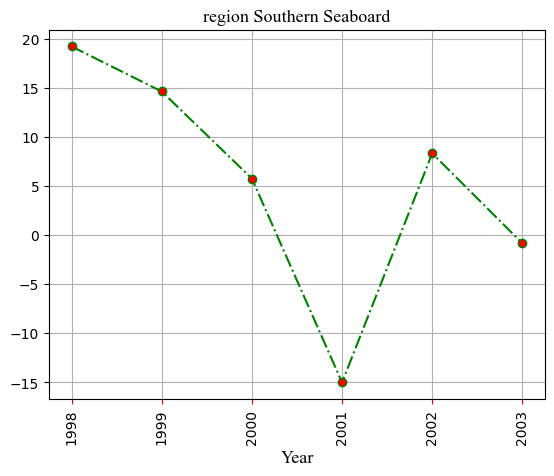

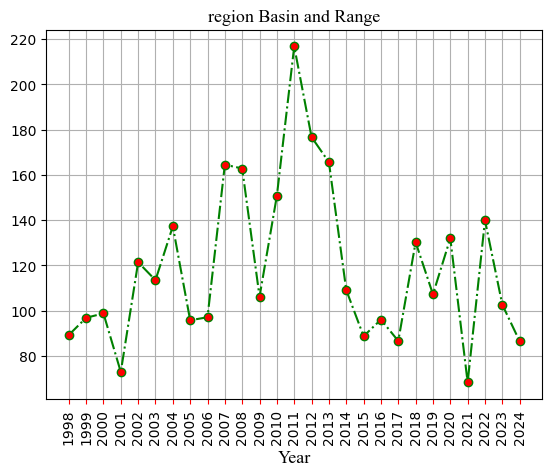

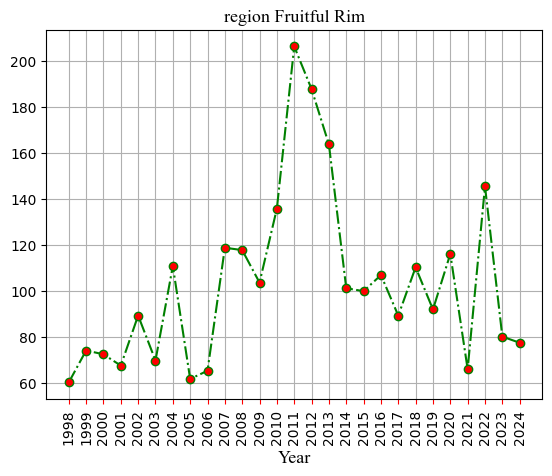

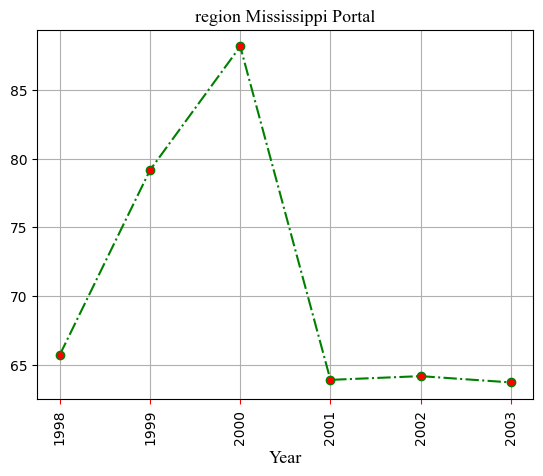

In [35]:
for i in df_region.region.unique():
    plt.plot( df_region.loc[df_region['region']==i, ['year']], df_region.loc[df_region['region']==i, ['return_on_operating_costs']], **line_style,
              linestyle = "dashdot",
              color="green", label= i)
    plt.title("region " + i,
              **tle_style, 
              color ="black")
    plt.xlabel("Year",
               **tle_style, 
               color ="black")
    plt.grid()
    plt.tick_params(axis="x", color = "red", labelrotation=90)
    plt.xticks(df_region.loc[df_region['region'] == i, 'year'].to_list())
    plt.show()

##### ROI
* The plot showing all the regions droping except Prairie Gateway region growing from 60 to 80

### By region analysis

In [36]:
regional_summary = df_region.groupby('region')[['total_gross_value_of_production', 
                                         'total_operating_costs',
                                         'value_after_cost']].mean()
regional_summary

,total_gross_value_of_production,total_operating_costs,value_after_cost
region,,,
Basin and Range,295.038519,133.885556,134.888519
Fruitful Rim,334.774074,162.201852,139.865556
Heartland,324.767037,152.683333,153.218148
Mississippi Portal,140.863333,82.560000,34.218333
Northern Crescent,375.838519,159.146296,188.997037
Northern Great Plains,219.753704,102.563333,98.887407
Prairie Gateway,171.046296,93.751852,62.165556
Southern Seaboard,102.846667,97.931667,-10.106667


##### Region summary mean

For 'total_operating_costs'
* Highest: 162.2, region: Fruitful Rim
* Lowest: 82.5 region: Mississippi Portal

For 'value_after_cost'
* Highest: 188.9, region: Northern Crescent
* Lowest: -10.1 region: Southern Seaboard 

In [37]:
regional_summary_median = df_region.groupby('region')[['total_gross_value_of_production', 
                                         'total_operating_costs',
                                         'value_after_cost']].median()
regional_summary_median

,total_gross_value_of_production,total_operating_costs,value_after_cost
region,,,
Basin and Range,284.950,139.460,118.51
Fruitful Rim,334.060,165.830,128.35
Heartland,298.370,171.750,119.43
Mississippi Portal,139.125,81.510,32.02
Northern Crescent,369.300,172.440,179.96
Northern Great Plains,239.160,109.810,108.61
Prairie Gateway,175.890,100.020,49.71
Southern Seaboard,102.595,97.885,-8.60


##### Region summary median

For 'total_operating_costs'
* Highest: 172.4, region: Northern Crescent
* Lowest: 81.5 region: Mississippi Portal

For 'value_after_cost'
* Highest: 179.9, region: Northern Crescent
* Lowest: -8.60 region: Southern Seaboard 

In [38]:
df_region.info()

<class 'pandas.DataFrame'>
Index: 174 entries, 1 to 241
Data columns (total 31 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   year                                         174 non-null    int64  
 1   region                                       174 non-null    str    
 2   capital_recovery_of_machinery_and_equipment  174 non-null    float64
 3   chemicals                                    174 non-null    float64
 4   custom_services                              174 non-null    float64
 5   fertilizer_1                                 174 non-null    float64
 6   fuel_lube_and_electricity                    174 non-null    float64
 7   general_farm_overhead                        174 non-null    float64
 8   hired_labor                                  174 non-null    float64
 9   interest_on_operating_inputs                 174 non-null    float64
 10  opportunity_cost_o

In [39]:
df_region_train = pd.concat([df_region.iloc[:,0:10],df_region.iloc[:,[12,14]], df_region.iloc[:,16:18],df_region.iloc[:,[20]]], axis=1)
df_region_train

,year,region,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,other_variable_expenses_2,repairs,seed,taxes_and_insurance,total_gross_value_of_production
1,1998,Heartland,38.60,3.76,6.46,37.91,4.36,7.21,1.30,1.76,0.50,7.19,13.25,3.26,139.55
2,1998,Northern Crescent,36.19,3.05,10.92,33.69,3.82,7.89,0.37,1.74,1.99,5.93,13.32,4.02,192.28
3,1998,Northern Great Plains,41.23,10.61,4.04,14.78,4.25,6.32,1.45,1.19,0.16,8.10,7.64,3.76,101.84
4,1998,Prairie Gateway,40.66,3.30,8.07,14.27,7.03,5.67,1.77,1.12,0.15,8.84,5.13,3.03,105.98
5,1998,Southern Seaboard,43.01,5.59,14.14,44.57,5.72,5.74,5.36,2.30,0.17,9.35,16.39,2.62,117.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,2024,Northern Crescent,142.40,26.16,17.55,98.22,13.33,11.08,2.29,5.34,2.77,33.33,30.85,6.45,549.11
237,2024,Northern Great Plains,147.08,21.94,11.47,51.78,8.98,11.98,1.94,3.44,0.26,31.35,17.42,8.53,262.76
238,2024,Prairie Gateway,117.70,9.53,17.90,50.69,13.46,11.80,2.95,3.25,0.40,29.93,13.31,6.26,252.00
240,2024,Basin and Range,135.15,32.95,17.16,65.40,15.95,15.52,5.16,4.53,0.80,34.23,22.03,13.72,359.99


In [49]:
df_region_train.iloc[:,2:].describe()

,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,other_variable_expenses_2,repairs,seed,taxes_and_insurance,total_gross_value_of_production
count,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000
mean,79.117586,13.926724,11.089943,51.297241,14.994080,11.565747,4.032874,1.286494,1.588103,19.260575,17.575345,7.312816,275.489368
std,30.392477,8.378562,4.253411,26.668664,11.057231,4.087519,3.354571,1.312130,2.332603,9.114251,9.106129,2.731644,134.329538
min,36.190000,2.860000,3.130000,13.330000,3.820000,5.670000,0.370000,0.030000,0.060000,5.930000,3.920000,2.620000,68.270000
25%,51.505000,6.962500,7.715000,32.065000,8.460000,8.627500,1.677500,0.167500,0.180000,10.730000,10.822500,5.237500,174.097500
50%,71.895000,12.040000,10.785000,44.715000,12.330000,10.905000,2.540000,0.945000,0.740000,16.830000,14.420000,7.250000,251.615000
75%,102.312500,21.047500,13.365000,64.635000,15.907500,13.832500,5.837500,1.962500,1.327500,26.027500,21.815000,8.765000,360.387500
max,156.630000,42.450000,23.040000,145.320000,79.810000,22.010000,18.600000,6.370000,9.520000,39.850000,40.340000,14.280000,677.470000


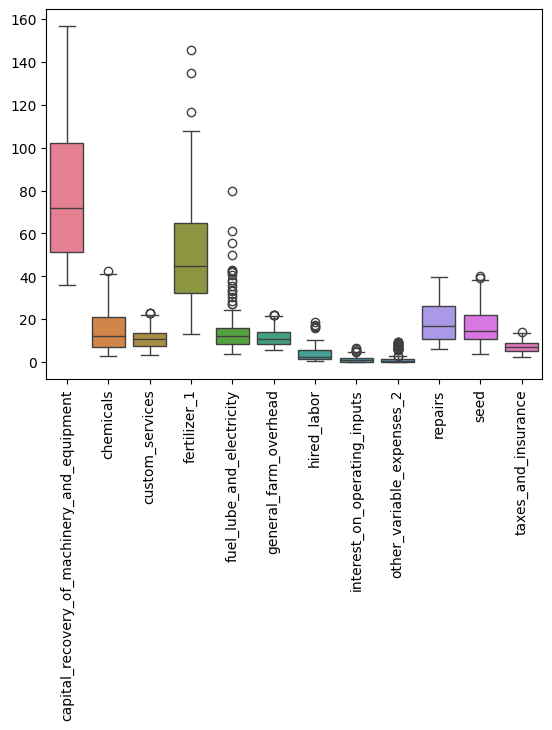

In [50]:
sns.boxplot(data=df_region_train.iloc[:,2:-1])
plt.xticks(rotation=90)
plt.show()

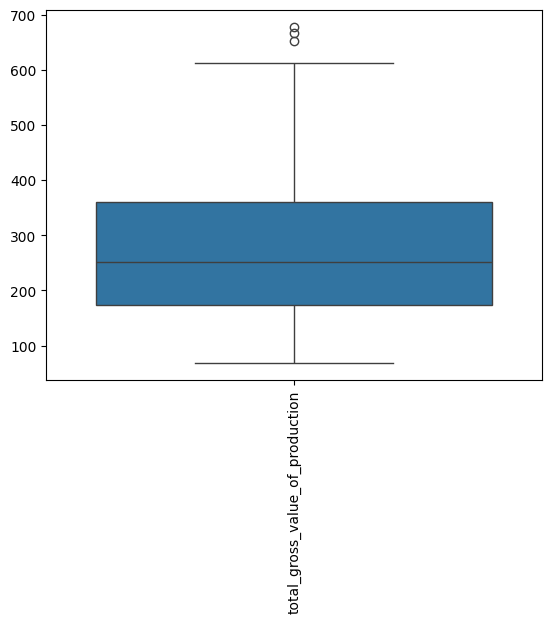

In [51]:
sns.boxplot(data=df_region_train.iloc[:,[-1]])
plt.xticks(rotation=90)
plt.show()

###### Box plot
* Matrix of Features: all the column is showing right skew and having small among of ouline except 'fuel_lube_and_electricity'
* Dependent variable: also right skew and showing outline
* The data for training is having ouline but will not remove ouline because it carry the time series type and also data is too small after split train test set

In [52]:
df_region_train.iloc[:,2:].corr()

,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,other_variable_expenses_2,repairs,seed,taxes_and_insurance,total_gross_value_of_production
capital_recovery_of_machinery_and_equipment,1.000000,0.826891,0.476160,0.475059,0.373428,0.492045,0.401971,0.279923,0.405035,0.965203,0.487231,0.503774,0.695872
chemicals,0.826891,1.000000,0.321160,0.402820,0.184269,0.384729,0.352693,0.283040,0.282335,0.784614,0.379541,0.466677,0.629436
custom_services,0.476160,0.321160,1.000000,0.370647,0.153567,0.348596,0.521748,0.195073,0.420893,0.538461,0.412193,0.167647,0.407194
fertilizer_1,0.475059,0.402820,0.370647,1.000000,0.052779,0.521050,-0.018856,0.204722,0.057289,0.416938,0.912712,0.467482,0.822487
fuel_lube_and_electricity,0.373428,0.184269,0.153567,0.052779,1.000000,0.332529,0.585094,0.038955,0.599866,0.466614,0.057590,0.322231,0.375117
general_farm_overhead,0.492045,0.384729,0.348596,0.521050,0.332529,1.000000,0.407389,-0.114198,0.462406,0.515119,0.666540,0.835882,0.631036
hired_labor,0.401971,0.352693,0.521748,-0.018856,0.585094,0.407389,1.000000,0.026734,0.785343,0.520201,0.076892,0.242678,0.225315
interest_on_operating_inputs,0.279923,0.283040,0.195073,0.204722,0.038955,-0.114198,0.026734,1.000000,0.064812,0.190430,0.131509,0.005352,0.183467
other_variable_expenses_2,0.405035,0.282335,0.420893,0.057289,0.599866,0.462406,0.785343,0.064812,1.000000,0.517772,0.159506,0.242097,0.353470
repairs,0.965203,0.784614,0.538461,0.416938,0.466614,0.515119,0.520201,0.190430,0.517772,1.000000,0.442296,0.472000,0.680221


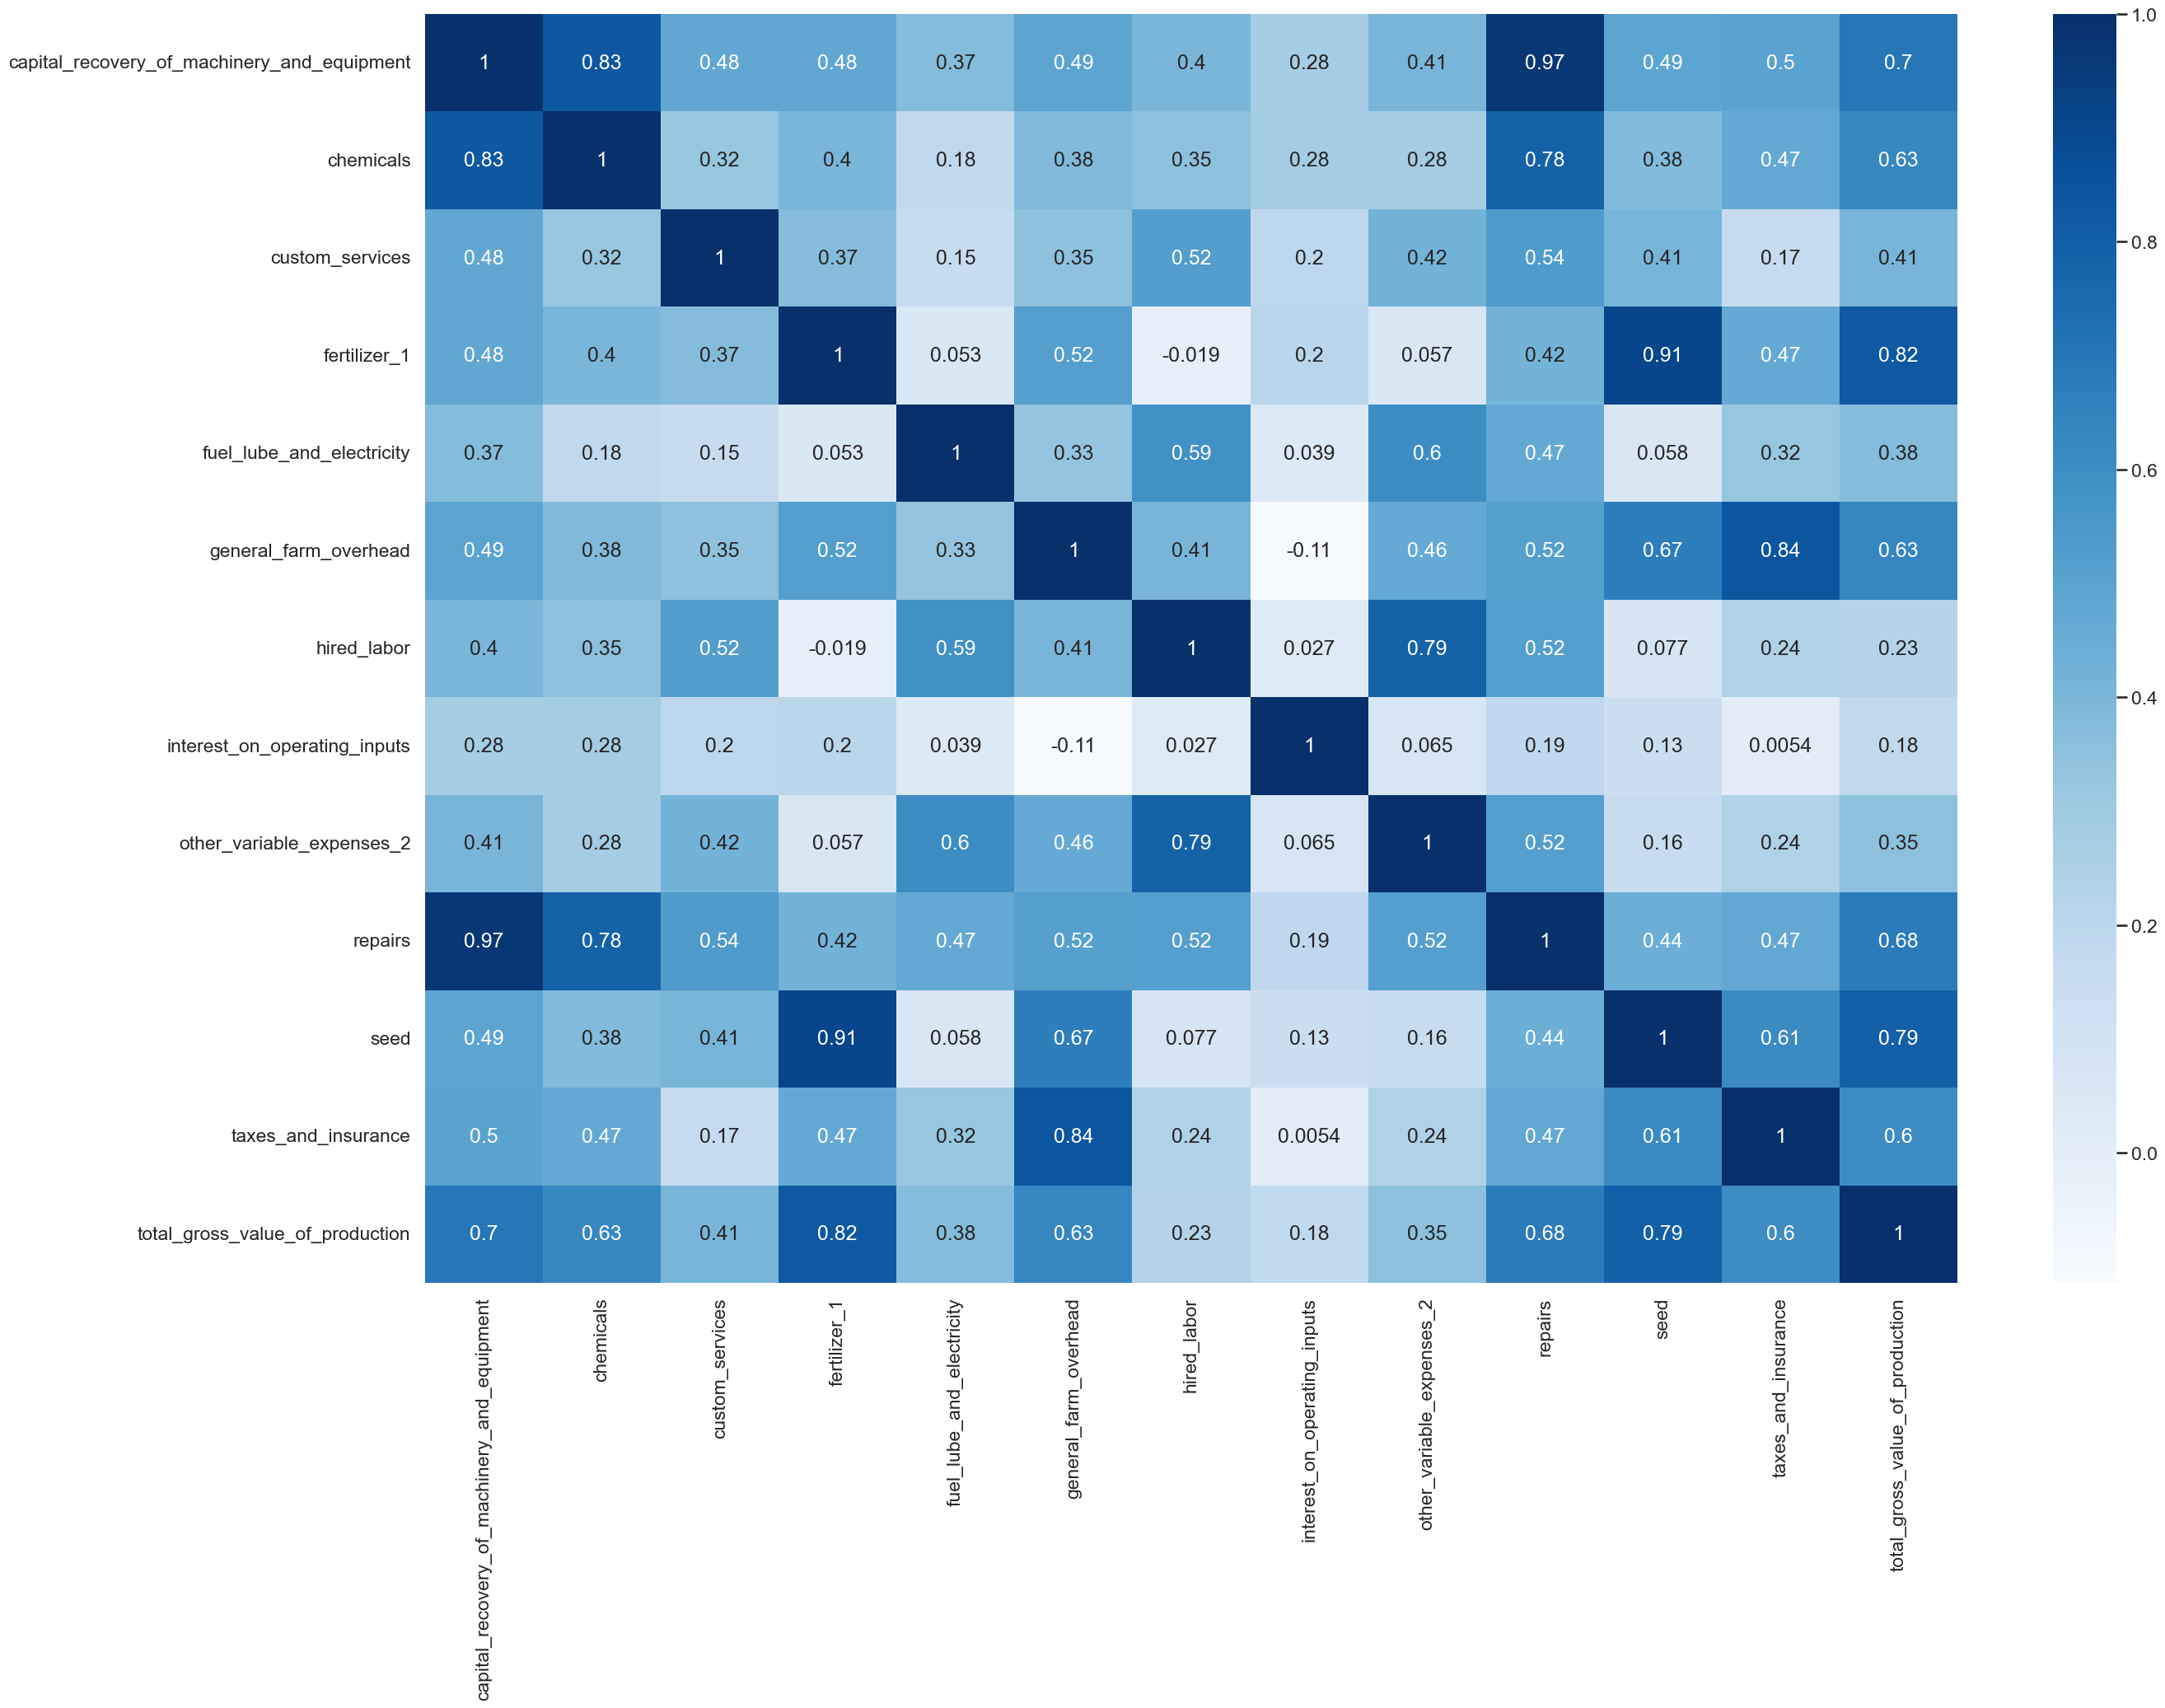

In [53]:
plt.figure(figsize=(30,20))
sns.set_style('dark')
sns.set_context('talk')
sns.heatmap(df_region_train.iloc[:,2:].corr(),
           annot=True,
           cmap='Blues')
plt.show()

###### correlation coefficient relationship to Dependent variable (total_gross_value_of_production)
* The high correlation coefficient include: 'fertilizer_1', 'seed', 'capital_recovery_of_machinery_and_equipment', 'repairs' all over 0.67
* The low correlation coefficient include: 'other_variable_expenses_2', 'hired_labor', 'interest_on_operating_inputs' all under 0.36

# Part III: Feature Engineering

##### Feature selection:
* Matrix of Features: 'year', 'region', 'capital_recovery_of_machinery_and_equipment', 'chemicals', 'custom_services', 'fertilizer_1', 'fuel_lube_and_electricity', 'general_farm_overhead', 'hired_labor', 'interest_on_operating_inputs', 'other_variable_expenses_2', 'repairs', 'seed', 'taxes_and_insurance'
* Dependent variable: 'total_gross_value_of_production'
* Drop: 'opportunity_cost_of_land', 'opportunity_cost_of_unpaid_labor', 'total_allocated_overhead', 'total_costs_listed', 'total_operating_costs', 'value_of_production_less_operating_costs', 'value_of_production_less_total_costs_listed', 'primary_product_grain', 'secondary_product_silage_straw_grazing'

Explain:
* Selected columns: which are important for the predict because they are affected to the production and 'total_gross_value_of_production' showing the profit of production
* Droped columns: which are the summarize the other column will make data duplicate like: 'total_operating_costs' and some of the column is just a opportunity cost just a predict and no data showing like 'opportunity_cost_of_land', 'opportunity_cost_of_unpaid_labor' will create noise the rest is the separate from Dependent variable like: 'primary_product_grain', 'secondary_product_silage_straw_grazing'

### Import Feature of Matrix and depending variable

In [54]:
col = df_region_train.pop('region')
df_region_train.insert(0, 'region', col)

In [55]:
df_region_train

,region,year,capital_recovery_of_machinery_and_equipment,chemicals,custom_services,fertilizer_1,fuel_lube_and_electricity,general_farm_overhead,hired_labor,interest_on_operating_inputs,other_variable_expenses_2,repairs,seed,taxes_and_insurance,total_gross_value_of_production
1,Heartland,1998,38.60,3.76,6.46,37.91,4.36,7.21,1.30,1.76,0.50,7.19,13.25,3.26,139.55
2,Northern Crescent,1998,36.19,3.05,10.92,33.69,3.82,7.89,0.37,1.74,1.99,5.93,13.32,4.02,192.28
3,Northern Great Plains,1998,41.23,10.61,4.04,14.78,4.25,6.32,1.45,1.19,0.16,8.10,7.64,3.76,101.84
4,Prairie Gateway,1998,40.66,3.30,8.07,14.27,7.03,5.67,1.77,1.12,0.15,8.84,5.13,3.03,105.98
5,Southern Seaboard,1998,43.01,5.59,14.14,44.57,5.72,5.74,5.36,2.30,0.17,9.35,16.39,2.62,117.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,Northern Crescent,2024,142.40,26.16,17.55,98.22,13.33,11.08,2.29,5.34,2.77,33.33,30.85,6.45,549.11
237,Northern Great Plains,2024,147.08,21.94,11.47,51.78,8.98,11.98,1.94,3.44,0.26,31.35,17.42,8.53,262.76
238,Prairie Gateway,2024,117.70,9.53,17.90,50.69,13.46,11.80,2.95,3.25,0.40,29.93,13.31,6.26,252.00
240,Basin and Range,2024,135.15,32.95,17.16,65.40,15.95,15.52,5.16,4.53,0.80,34.23,22.03,13.72,359.99


In [56]:
X = df_region_train.iloc[:, :-1].values
y = df_region_train.iloc[:, -1].values

## Encoding categorical data

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [58]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

## Splitting the dataset into the Training set and Test set

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [61]:
X_train[0]

array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2011, 62.46, 8.88, 10.7,
       100.84, 14.29, 13.2, 1.54, 0.09, 0.46, 14.57, 25.81, 6.65],
      dtype=object)

## Feature Scaling

In [62]:
from sklearn.preprocessing import RobustScaler

In [63]:
sc = RobustScaler()
X_train[:, 8:] = sc.fit_transform(X_train[:, 8:])
X_test[:, 8:] = sc.transform(X_test[:, 8:])

In [64]:
X_train[0]

array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.06896551724137931,
       -0.21791235934498215, -0.3987465726596161, -0.03946188340807186,
       1.6715596330275229, 0.2401601067378251, 0.45858585858585854,
       -0.2093784078516903, -0.556473829201102, -0.17366946778711484,
       -0.14867485455720755, 0.9565623540401682, -0.18579234972677597],
      dtype=object)

In [65]:
y_train_1 = y_train[:, np.newaxis]
y_train_1

array([[387.12],
       [355.93],
       [428.44],
       [263.2 ],
       [208.06],
       [209.27],
       [208.98],
       [181.23],
       [130.64],
       [132.37],
       [102.05],
       [196.58],
       [227.64],
       [ 85.67],
       [188.65],
       [255.58],
       [285.07],
       [350.45],
       [108.41],
       [306.84],
       [285.37],
       [ 87.69],
       [271.73],
       [356.6 ],
       [295.01],
       [298.37],
       [192.96],
       [363.28],
       [450.91],
       [543.81],
       [155.31],
       [348.18],
       [203.73],
       [453.68],
       [ 98.7 ],
       [335.79],
       [611.88],
       [360.52],
       [252.  ],
       [321.63],
       [164.88],
       [284.95],
       [101.84],
       [298.12],
       [398.15],
       [173.5 ],
       [278.54],
       [139.55],
       [549.11],
       [435.26],
       [229.7 ],
       [243.82],
       [250.16],
       [313.31],
       [208.36],
       [141.64],
       [340.88],
       [502.57],
       [368.87

In [66]:
y_test_1 = y_test[:, np.newaxis]
y_test_1

array([[208.19],
       [268.9 ],
       [ 73.29],
       [151.32],
       [232.43],
       [165.94],
       [351.31],
       [180.68],
       [401.87],
       [313.56],
       [ 83.96],
       [117.09],
       [213.62],
       [126.27],
       [430.81],
       [282.01],
       [350.09],
       [ 68.27],
       [185.18],
       [148.78],
       [108.04],
       [276.68],
       [489.92],
       [423.49],
       [212.17],
       [361.89],
       [142.39],
       [157.4 ],
       [143.23],
       [517.99],
       [283.25],
       [364.68],
       [157.25],
       [159.12],
       [537.45]])

In [67]:
sc_y = RobustScaler()
y_train_1 = sc_y.fit_transform(y_train_1)
y_test_1 = sc_y.transform(y_test_1)

# Part IV Training model

## Training model on the Training set

In [68]:
df_eva = pd.DataFrame(columns=['model_name', 'train_r_square', 'test_r_square', 'MSE', 'RMSE', 'MAE', 'adj_r_square'])
df_eva['model_name'] = ['Multi Linear Regression', 'Polinormial Regression', 'Support Vector Regression']
df_eva

,model_name,train_r_square,test_r_square,MSE,RMSE,MAE,adj_r_square
0,Multi Linear Regression,NaN,NaN,NaN,NaN,NaN,NaN
1,Polinormial Regression,NaN,NaN,NaN,NaN,NaN,NaN
2,Support Vector Regression,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print(regressor.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [70]:
train_score = regressor.score(X_train, y_train)
df_eva.iloc[0,1] = train_score
print(f"Training R² Score: {train_score:.4f}")

Training R² Score: 0.9248


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [72]:
# Create a pipeline that handles everything automatically
poly_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('linear_reg', LinearRegression())
])

# Fit on training data (automatically handles transformation)
poly_regression.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [73]:
train_score = poly_regression.score(X_train, y_train)
df_eva.iloc[1,1] = train_score
print(f"Training R² Score: {train_score:.4f}")

Training R² Score: 1.0000


In [74]:
from sklearn.svm import SVR
regressor_2 = SVR(kernel = 'rbf')
regressor_2.fit(X_train, y_train_1)

C:\Users\JOHN\.conda\envs\cenv2\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [75]:
train_score = regressor_2.score(X_train, y_train_1)
df_eva.iloc[2,1] = train_score
print(f"Training R² Score: {train_score:.4f}")

Training R² Score: 0.9504


## Predicting the Test set results

In [76]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)), 1))

[[231.02 208.19]
 [356.49 268.9 ]
 [ 76.87  73.29]
 [185.64 151.32]
 [147.97 232.43]
 [172.49 165.94]
 [417.83 351.31]
 [160.32 180.68]
 [365.84 401.87]
 [363.17 313.56]
 [ 65.33  83.96]
 [108.75 117.09]
 [237.85 213.62]
 [126.16 126.27]
 [411.48 430.81]
 [289.45 282.01]
 [291.18 350.09]
 [ 76.16  68.27]
 [156.93 185.18]
 [166.5  148.78]
 [120.24 108.04]
 [285.22 276.68]
 [475.26 489.92]
 [482.14 423.49]
 [163.48 212.17]
 [327.54 361.89]
 [147.88 142.39]
 [189.82 157.4 ]
 [133.94 143.23]
 [423.43 517.99]
 [284.22 283.25]
 [452.48 364.68]
 [153.69 157.25]
 [176.92 159.12]
 [424.31 537.45]]


In [77]:
y_pred_1 = poly_regression.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_1.reshape(len(y_pred_1),1), y_test.reshape(len(y_test),1)), 1))

[[293.84 208.19]
 [286.77 268.9 ]
 [ 59.38  73.29]
 [127.59 151.32]
 [184.42 232.43]
 [179.76 165.94]
 [354.11 351.31]
 [173.17 180.68]
 [372.95 401.87]
 [318.67 313.56]
 [ 85.31  83.96]
 [103.61 117.09]
 [277.78 213.62]
 [141.72 126.27]
 [441.47 430.81]
 [253.5  282.01]
 [256.45 350.09]
 [ 50.24  68.27]
 [198.73 185.18]
 [163.04 148.78]
 [ 86.2  108.04]
 [568.27 276.68]
 [497.07 489.92]
 [610.27 423.49]
 [217.44 212.17]
 [232.49 361.89]
 [ 99.65 142.39]
 [149.19 157.4 ]
 [126.41 143.23]
 [448.33 517.99]
 [377.45 283.25]
 [574.44 364.68]
 [223.38 157.25]
 [202.62 159.12]
 [534.16 537.45]]


In [78]:
y_pred_2 = regressor_2.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_2.reshape(len(y_pred_2),1), y_test_1.reshape(len(y_test_1),1)), 1))

[[-0.19 -0.31]
 [ 0.46  0.03]
 [-1.   -1.08]
 [-0.63 -0.63]
 [-0.21 -0.17]
 [-0.42 -0.55]
 [ 0.61  0.5 ]
 [-0.44 -0.47]
 [ 0.73  0.79]
 [ 0.74  0.29]
 [-0.95 -1.02]
 [-0.83 -0.83]
 [-0.11 -0.28]
 [-0.86 -0.78]
 [ 0.8   0.96]
 [ 0.22  0.11]
 [ 0.13  0.5 ]
 [-0.9  -1.11]
 [-0.48 -0.44]
 [-0.57 -0.65]
 [-0.84 -0.88]
 [-0.11  0.08]
 [ 1.53  1.29]
 [ 1.03  0.91]
 [-0.54 -0.29]
 [ 0.56  0.56]
 [-0.55 -0.68]
 [-0.4  -0.6 ]
 [-0.71 -0.68]
 [ 0.84  1.45]
 [ 0.19  0.12]
 [ 0.98  0.58]
 [-0.35 -0.6 ]
 [-0.53 -0.59]
 [ 0.95  1.56]]


In [79]:
sc_y.inverse_transform(y_pred_2[:, np.newaxis])
print(sc_y.inverse_transform(np.concatenate((y_pred_2.reshape(len(y_pred_2),1), y_test_1.reshape(len(y_test_1),1)), 1)))

[[229.44 208.19]
 [343.47 268.9 ]
 [ 86.92  73.29]
 [152.52 151.32]
 [225.72 232.43]
 [188.5  165.94]
 [369.47 351.31]
 [184.71 180.68]
 [391.79 401.87]
 [392.32 313.56]
 [ 96.55  83.96]
 [116.66 117.09]
 [243.02 213.62]
 [110.84 126.27]
 [404.22 430.81]
 [300.96 282.01]
 [285.6  350.09]
 [104.47  68.27]
 [178.18 185.18]
 [161.83 148.78]
 [114.21 108.04]
 [243.35 276.68]
 [532.35 489.92]
 [443.43 423.49]
 [168.04 212.17]
 [360.48 361.89]
 [166.3  142.39]
 [193.21 157.4 ]
 [137.97 143.23]
 [409.92 517.99]
 [296.01 283.25]
 [435.05 364.68]
 [201.56 157.25]
 [169.86 159.12]
 [429.6  537.45]]


## Evaluation

In [80]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [81]:
#  R-Square Evaluation
r2 = r2_score(y_test, y_pred)
print(f"\n📈 R-Squared Score: {r2:.4f}")

# Additional metrics for comprehensive evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📊 Mean Absolute Error (MAE): {mae:.4f}")

# Adjusted R-Squared (accounts for number of features)
n = X_test.shape[0]  # number of samples
k = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1-r2) * (n-1)/(n-k-1)
print(f"🎯 Adjusted R-Squared: {adjusted_r2:.4f}")
df_eva.iloc[0,2] = r2
df_eva.iloc[0,3] = mse
df_eva.iloc[0,4] = rmse
df_eva.iloc[0,5] = mae
df_eva.iloc[0,6] = adjusted_r2


📈 R-Squared Score: 0.8810
📉 Mean Squared Error (MSE): 1988.8815
📉 Root Mean Squared Error (RMSE): 44.5969
📊 Mean Absolute Error (MAE): 32.7089
🎯 Adjusted R-Squared: 0.6889


In [82]:
#  R-Square Evaluation
r2 = r2_score(y_test, y_pred_1)
print(f"\n📈 R-Squared Score: {r2:.4f}")

# Additional metrics for comprehensive evaluation
mse = mean_squared_error(y_test, y_pred_1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_1)

print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📊 Mean Absolute Error (MAE): {mae:.4f}")

# Adjusted R-Squared (accounts for number of features)
n = X_test.shape[0]  # number of samples
k = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1-r2) * (n-1)/(n-k-1)
print(f"🎯 Adjusted R-Squared: {adjusted_r2:.4f}")
df_eva.iloc[1,2] = r2
df_eva.iloc[1,3] = mse
df_eva.iloc[1,4] = rmse
df_eva.iloc[1,5] = mae
df_eva.iloc[1,6] = adjusted_r2


📈 R-Squared Score: 0.6067
📉 Mean Squared Error (MSE): 6576.2300
📉 Root Mean Squared Error (RMSE): 81.0940
📊 Mean Absolute Error (MAE): 49.0502
🎯 Adjusted R-Squared: -0.0287


In [83]:
y_test_1

array([[-0.31],
       [ 0.03],
       [-1.08],
       [-0.63],
       [-0.17],
       [-0.55],
       [ 0.5 ],
       [-0.47],
       [ 0.79],
       [ 0.29],
       [-1.02],
       [-0.83],
       [-0.28],
       [-0.78],
       [ 0.96],
       [ 0.11],
       [ 0.5 ],
       [-1.11],
       [-0.44],
       [-0.65],
       [-0.88],
       [ 0.08],
       [ 1.29],
       [ 0.91],
       [-0.29],
       [ 0.56],
       [-0.68],
       [-0.6 ],
       [-0.68],
       [ 1.45],
       [ 0.12],
       [ 0.58],
       [-0.6 ],
       [-0.59],
       [ 1.56]])

In [84]:
#  R-Square Evaluation
r2 = r2_score(y_test_1, y_pred_2)
print(f"\n📈 R-Squared Score: {r2:.4f}")

# Additional metrics for comprehensive evaluation
mse = mean_squared_error(y_test_1, y_pred_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_1, y_pred_2)

print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📊 Mean Absolute Error (MAE): {mae:.4f}")

# Adjusted R-Squared (accounts for number of features)
n = X_test.shape[0]  # number of samples
k = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1-r2) * (n-1)/(n-k-1)
print(f"🎯 Adjusted R-Squared: {adjusted_r2:.4f}")
df_eva.iloc[2,2] = r2
df_eva.iloc[2,3] = mse
df_eva.iloc[2,4] = rmse
df_eva.iloc[2,5] = mae
df_eva.iloc[2,6] = adjusted_r2


📈 R-Squared Score: 0.8990
📉 Mean Squared Error (MSE): 0.0546
📉 Root Mean Squared Error (RMSE): 0.2337
📊 Mean Absolute Error (MAE): 0.1692
🎯 Adjusted R-Squared: 0.7358


In [85]:
df_eva = df_eva.set_index('model_name')

df_eva

,train_r_square,test_r_square,MSE,RMSE,MAE,adj_r_square
model_name,,,,,,
Multi Linear Regression,0.924793,0.881044,1988.881526,44.596878,32.708887,0.688883
Polinormial Regression,1.0,0.606671,6576.230042,81.093958,49.050167,-0.028707
Support Vector Regression,0.950407,0.899,0.054596,0.233657,0.169211,0.735846


#### After training and evaluation multiple models
* Reason: selected this 3 model because it suitable for training this small dataset
* Selected model: 'Support Vector Regression' this model selected because it's show the best of all three in data showing and not overfitting
* Evaluation model selected: train_r_square: 0.95, test_r_square: 0.89, MSE: 0.05, RMSE: 0.23,MAE: 0.16,adj_r_square: 0.73